# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Anastia Firyal Nisrina
- **Email:** anastianisrina06@gmail.com
- **ID Dicoding:** anastia_06

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Produk apa yang paling banyak dan paling sedikit terjual?
- Pertanyaan 2 : Berapa banyak uang yang dihabiskan pelanggan dalam beberapa bulan terakhir?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
#Tabel Customer
customers_df = pd.read_csv("customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
#Tabel Orders
orders_df = pd.read_csv("orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
#Tabel Product
product_df = pd.read_csv("order_items_dataset.csv")
product_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
#Tabel Seller
seller_df = pd.read_csv("sellers_dataset.csv")
seller_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Berhasil memuat 4 dataset utama yang dibutuhkan untuk analisis, yaitu `customers_dataset.csv`, `orders_dataset.csv`, `order_items_dataset.csv`, dan `sellers_dataset.csv`.
- Masing-masing dataset memiliki kolom kunci (`customer_id`, `order_id`, `product_id`, `seller_id`) yang nantinya digunakan untuk proses penggabungan (merge) antar tabel pada tahap berikutnya.

### Assessing Data

In [ ]:
#Menilai Data Customers
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [ ]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [ ]:
#Menilai Data Orders
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   delivery_time                  96475 non-null  float64       
dtypes: datetime64[ns](5), float64(1), object(3)
memory usage: 6.8+ MB


In [ ]:
print("Jumlah duplikasi: ",orders_df.duplicated().sum())
orders_df.describe()

Jumlah duplikasi:  0


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
count,99441,99281,97658,96476,99441,96475.000000
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,9.292314
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,-16.000000
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,4.000000
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,7.000000
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,12.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,205.000000
std,NaN,NaN,NaN,NaN,NaN,8.776671


In [ ]:
#Menilai Data Product
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
print("Jumlah duplikasi: ", product_df.duplicated().sum())

product_df.describe()

Jumlah duplikasi:  0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [ ]:
#Menilai Data Sales
seller_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [ ]:
seller_df.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [ ]:
print("Jumlah duplikasi: ", seller_df.duplicated().sum())
seller_df.describe()

Jumlah duplikasi:  0


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


**Insight:**
- Tidak ditemukan data duplikat pada keempat dataset (`customers_df`, `orders_df`, `product_df`, `seller_df`).
- Terdapat missing value pada beberapa kolom tanggal di `orders_df`, yaitu `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date` — kemungkinan besar berasal dari order yang belum diproses/dibatalkan sehingga belum memiliki tanggal approval atau pengiriman.
- Ditemukan potensi inaccurate value pada `customer_zip_code_prefix`, di mana nilai maksimumnya (99990) tercatat sama persis dengan nilai yang muncul di kolom `customer_city`, sehingga perlu penanganan lebih lanjut pada tahap cleaning.
- Kolom `price` pada `product_df` memiliki rentang yang cukup lebar (0.85 hingga 6.735), yang mengindikasikan adanya variasi harga produk yang tinggi dan berpotensi mengandung outlier.

### Cleaning Data

In [ ]:
#Cleaning Data Customer
customers_df.drop_duplicates(inplace=True)

In [ ]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
#Menangani Missing Value
customers_df[customers_df.customer_state.isna()]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,status


In [ ]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0
status,0


In [ ]:
#Mengangani Inaccurate Value
customers_df[customers_df.customer_zip_code_prefix == customers_df.customer_zip_code_prefix.max()]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,status
25752,f04c3f6e20a2a4318d97d7cec1d27bbf,8f846b30f8f56368cd1bf4c89efeed74,99990,muliterno,RS,Active


In [ ]:
customers_df.customer_city.replace(customers_df.customer_zip_code_prefix.max(), 99990 , inplace=True)

In [ ]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [ ]:
#Cleaning Data Orders
datetime_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]

for column in datetime_columns:
  orders_df[column] = pd.to_datetime(orders_df[column])

In [ ]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   delivery_time                  96475 non-null  float64       
dtypes: datetime64[ns](5), float64(1), object(3)
memory usage: 6.8+ MB


In [ ]:
#Cleaning Data Product
product_df.drop_duplicates(inplace=True)

In [ ]:
print("Jumlah duplikasi: ", product_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
#Cleaning Data Seller
seller_df.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [ ]:
print("Jumlah duplikasi: ", seller_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Data duplikat pada `customers_df` berhasil dihapus, dan hasil pengecekan ulang menunjukkan jumlah duplikasi menjadi 0.
- Missing value pada `customer_state` dan kolom lain di `customers_df` telah dicek ulang dan tidak ditemukan nilai yang kosong setelah proses cleaning.
- Seluruh kolom bertipe tanggal pada `orders_df` (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) berhasil dikonversi ke tipe data `datetime`, sehingga siap digunakan untuk analisis time-series.
- Setelah proses cleaning, keempat dataset (customers, orders, product, seller) sudah dalam kondisi bersih dan konsisten, sehingga siap digabungkan (merge) untuk tahap Exploratory Data Analysis (EDA).

## Exploratory Data Analysis (EDA)

### Explore Data Customer

In [ ]:
customers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,status
count,99441,99441,99441.000000,99441,99441,99441
unique,99441,96096,NaN,4119,27,1
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP,Active
freq,1,17,NaN,15540,41746,99441
mean,NaN,NaN,35137.474583,NaN,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN,NaN


In [ ]:
customers_df.groupby(by="customer_zip_code_prefix").agg({
    "customer_id": "nunique",
    "customer_zip_code_prefix": ["max", "min", "mean", "std"]
})

customer_id customer_zip_code_prefix                  \
                             nunique                      max    min     mean   
customer_zip_code_prefix                                                        
1003                               1                     1003   1003   1003.0   
1004                               2                     1004   1004   1004.0   
1005                               6                     1005   1005   1005.0   
1006                               2                     1006   1006   1006.0   
1007                               4                     1007   1007   1007.0   
...                              ...                      ...    ...      ...   
99960                              2                    99960  99960  99960.0   
99965                              2                    99965  99965  99965.0   
99970                              1                    99970  99970  99970.0   
99980                              2                    99980  99980  99980.0   
99990                              1                    99990  99990  99990.0   

                               
                          std  
customer_zip_code_prefix       
1003                      NaN  
1004                      0.0  
1005                      0.0  
1006                      0.0  
1007                      0.0  
...                       ...  
99960                     0.0  
99965                     0.0  
99970                     NaN  
99980                     0.0  
99990                     NaN  

[14994 rows x 5 columns]

Berdasarkan pivot table di atas, dapat diketahui bahwa pelanggan yang kita miliki didominasi oleh costumer yang berada pada zip code 1005.

In [ ]:
customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


In [ ]:
customers_df.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
santa salete,1
santa rosa do sul,1
cocalzinho de goias,1


Berdasarkan hasil di atas, dapat dilihat bahwa persebaran pelanggan kita cukup merata pada setiap kota dan negara bagian. Pelanggan kita paling banyak berada di kota Sao Paulo dengan jumlah 15.540 pelanggan. Selain itu, pelanggan kita paling banyak berasal dari negara bagian SP.

### Explore Data Order

In [ ]:
delivery_time = orders_df["order_delivered_customer_date"] - orders_df["order_delivered_carrier_date"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds())
orders_df["delivery_time"] = round(delivery_time/86400)

print(orders_df["delivery_time"])

0         6.0
1        12.0
2         9.0
3         9.0
4         2.0
         ... 
99436     7.0
99437    21.0
99438    24.0
99439    13.0
99440     7.0
Name: delivery_time, Length: 99441, dtype: float64


In [ ]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
count,99441,99441,99441,99441,99281,97658,96476,99441,96475.000000
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN,NaN
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,9.292314
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,-16.000000
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,4.000000
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,7.000000
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,12.000000
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,205.000000


Berdasarkan hasil tersebut, dapat diketahui bahwa rata-rata waktu pengiriman sebesar 9 hari dengan nilai maksimum sebesar 205 hari dan nilai minimum sebesar 16 hari.

### Explore Data Order dan Customer Order

In [ ]:
customer_id_in_orders_df =  orders_df.customer_id.tolist()
customers_df["status"] = customers_df["customer_id"].apply(lambda x: "Active" if x in customer_id_in_orders_df else "Non Active")
customers_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,status
17256,7d6c81f79e5c42187c42bf6af52ac046,f3eccc77c18fd4481d031db5d7f8b3f1,12244,sao jose dos campos,SP,Active
14832,ece0add9b18630501bd9a4020bbf2637,5a740d409f9eed7b1051a2b08f8198a5,13049,campinas,SP,Active
26323,2ebd763628be3025a1a9804ee59e2f3c,5b235808ec42268572ff15737d424210,88310,itajai,SC,Active
86644,4471480a2199c933b05f842342a6c57a,859f40a26e8b81608c6d035211098e9b,5640,sao paulo,SP,Active
29185,c6dafa651522bb3afcb52a2b558f3236,740075865af950b7f052f3cd7303241c,48485,satiro dias,BA,Active


In [ ]:
customers_df.groupby(by="status").customer_id.count()

,customer_id
status,
Active,99441


Seperti yang terlihat pada pivot table di atas, seluruh pelanggan yang terdapat di dalam dataset tersebut memiliki status "active", oleh karena itu seluruh pelanggan pernah melakukan order setidaknya sekali.

In [ ]:
orders_customers_df = pd.merge(
    left=orders_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)
orders_customers_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [ ]:
#Jumlah Order Berdasarkan Kota
orders_customers_df.groupby(by="customer_city").order_id.nunique().sort_values(ascending=False).reset_index().head(10)

,customer_city,order_id
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521
5,campinas,1444
6,porto alegre,1379
7,salvador,1245
8,guarulhos,1189
9,sao bernardo do campo,938


Nah, berdasarkan hasil tersebut, diketahui bahwa kota Sao Paulo merupakan kota yang memiliki jumlah order terbanyak.

In [ ]:
#Jumlah Order Berdasarkan State
orders_customers_df.groupby(by="customer_state").order_id.nunique().sort_values(ascending=False)

,order_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


Kode tersebut akan menghasilkan pivot table seperti di bawah ini. Berdasarkan pivot table tersebut, diketahui bahwa SP merupakan state yang paling banyak melakukan order.

### Explore Data Produk dan Seller

In [ ]:
seller_df.describe(include="all")

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


In [ ]:
product_df.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


Berdasarkan hasil tersebut, dapat dilihat bahwa harga barang yang dijual berkisar antara 0.85 hingga 6.735 dolar.


In [ ]:
product_df.sort_values(by="price", ascending=False)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.00,194.31
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.00,193.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.00,227.66
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.00,151.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.00,74.34
...,...,...,...,...,...,...,...
57304,8272b63d03f5f79c56e9e4120aec44ef,8,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57300,8272b63d03f5f79c56e9e4120aec44ef,4,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
48625,6e864b3f0ec71031117ad4cf46b7f2a1,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-02 20:30:34,0.85,18.23
27652,3ee6513ae7ea23bdfab5b9ab60bffcb5,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-04 03:55:26,0.85,18.23


In [ ]:
product_df.groupby(by="seller_id").agg({
    "product_id": "nunique",
    "order_item_id": "sum",
    "price":  ["min", "max"]
})

product_df.groupby(by="product_id").agg({
    "product_id": "nunique",
    "order_item_id": "sum",
    "price": ["min", "max"]
})

product_id order_item_id   price        
                                    nunique           sum     min     max
product_id                                                               
00066f42aeeb9f3007548bb9d3f33c38          1             1  101.65  101.65
00088930e925c41fd95ebfe695fd2655          1             1  129.90  129.90
0009406fd7479715e4bef61dd91f2462          1             1  229.00  229.00
000b8f95fcb9e0096488278317764d19          1             2   58.90   58.90
000d9be29b5207b54e86aa1b1ac54872          1             1  199.00  199.00
...                                     ...           ...     ...     ...
fff6177642830a9a94a0f2cba5e476d1          1             2  109.99  119.99
fff81cc3158d2725c0655ab9ba0f712c          1             1   90.00   90.00
fff9553ac224cec9d15d49f5a263411f          1             1   32.00   32.00
fffdb2d0ec8d6a61f0a0a0db3f25b441          1             5   29.99   34.99
fffe9eeff12fcbd74a2f2b007dde0c58          1             1  249.99  249.99

[32951 rows x 4 columns]

In [ ]:
seller_product_df = pd.merge(
    left=seller_df,
    right=product_df,
    how="right",
    left_on="seller_id",
    right_on="seller_id"
)
seller_product_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value
0,48436dade18ac8b2bce089ec2a041202,27277,volta redonda,SP,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,2017-09-19 09:45:35,58.90,13.29
1,dd7ddc04e1b6c2c614352b383efe2d36,3471,sao paulo,SP,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,2017-05-03 11:05:13,239.90,19.93
2,5b51032eddd242adc84c38acab88f23d,37564,borda da mata,MG,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,2018-01-18 14:48:30,199.00,17.87
3,9d7a1d34a5052409006425275ba1c2b4,14403,franca,SP,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,2018-08-15 10:10:18,12.99,12.79
4,df560393f3a51e74553ab94004ba5c87,87900,loanda,PR,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,2017-02-13 13:57:51,199.90,18.14


In [ ]:
seller_product_df.groupby(by="product_id").agg({
    "seller_id": "nunique",
    "product_id": "sum",
    "price": "sum"
})

,seller_id,product_id,price
product_id,,,
00066f42aeeb9f3007548bb9d3f33c38,1,00066f42aeeb9f3007548bb9d3f33c38,101.65
00088930e925c41fd95ebfe695fd2655,1,00088930e925c41fd95ebfe695fd2655,129.90
0009406fd7479715e4bef61dd91f2462,1,0009406fd7479715e4bef61dd91f2462,229.00
000b8f95fcb9e0096488278317764d19,1,000b8f95fcb9e0096488278317764d19000b8f95fcb9e0...,117.80
000d9be29b5207b54e86aa1b1ac54872,1,000d9be29b5207b54e86aa1b1ac54872,199.00
...,...,...,...
fff6177642830a9a94a0f2cba5e476d1,1,fff6177642830a9a94a0f2cba5e476d1fff6177642830a...,229.98
fff81cc3158d2725c0655ab9ba0f712c,1,fff81cc3158d2725c0655ab9ba0f712c,90.00
fff9553ac224cec9d15d49f5a263411f,1,fff9553ac224cec9d15d49f5a263411f,32.00


In [ ]:
seller_product_df.groupby(by="product_id").agg({
    "seller_id": "nunique",
    "product_id": "sum",
    "price": "sum"
}).sort_values(by="price", ascending=False)

,seller_id,product_id,price
product_id,,,
bb50f2e236e5eea0100680137654686c,1,bb50f2e236e5eea0100680137654686cbb50f2e236e5ee...,63885.00
6cdd53843498f92890544667809f1595,1,6cdd53843498f92890544667809f15956cdd53843498f9...,54730.20
d6160fb7873f184099d9bc95e30376af,1,d6160fb7873f184099d9bc95e30376afd6160fb7873f18...,48899.34
d1c427060a0f73f6b889a5c7c61f2ac4,1,d1c427060a0f73f6b889a5c7c61f2ac4d1c427060a0f73...,47214.51
99a4788cb24856965c36a24e339b6058,2,99a4788cb24856965c36a24e339b605899a4788cb24856...,43025.56
...,...,...,...
2e8316b31db34314f393806fd7b6e185,1,2e8316b31db34314f393806fd7b6e185,2.99
680cc8535be7cc69544238c1d6a83fe8,1,680cc8535be7cc69544238c1d6a83fe8,2.90
8a3254bee785a526d548a81a9bc3c9be,1,8a3254bee785a526d548a81a9bc3c9be8a3254bee785a5...,2.55


### Explore Data all_df

In [ ]:
all_df = pd.merge(
    left=seller_product_df,
    right=orders_customers_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)
all_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value,...,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,48436dade18ac8b2bce089ec2a041202,27277,volta redonda,SP,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,2017-09-19 09:45:35,58.90,13.29,...,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,dd7ddc04e1b6c2c614352b383efe2d36,3471,sao paulo,SP,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,2017-05-03 11:05:13,239.90,19.93,...,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,5b51032eddd242adc84c38acab88f23d,37564,borda da mata,MG,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,2018-01-18 14:48:30,199.00,17.87,...,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3,9d7a1d34a5052409006425275ba1c2b4,14403,franca,SP,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,2018-08-15 10:10:18,12.99,12.79,...,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4,df560393f3a51e74553ab94004ba5c87,87900,loanda,PR,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,2017-02-13 13:57:51,199.90,18.14,...,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP


In [ ]:
all_df.groupby(by=["customer_state", "product_id"]).agg({
    "product_id": "sum",
    "price": "sum"
})

product_id  \
customer_state product_id                                                           
AC             02475368dfb38934fe55f574024fe1d7  02475368dfb38934fe55f574024fe1d7   
               0798196b28c04c8e543322896c882902  0798196b28c04c8e543322896c882902   
               09dbbe2c4f26cad4d560aea043f9632c  09dbbe2c4f26cad4d560aea043f9632c   
               0a41699cb57f40c605d3cfdddd61673b  0a41699cb57f40c605d3cfdddd61673b   
               0a4dea9eaeaaea5b7894a9a4ec6ed660  0a4dea9eaeaaea5b7894a9a4ec6ed660   
...                                                                           ...   
TO             fe406983ad8b9e20a5b18801f39ece27  fe406983ad8b9e20a5b18801f39ece27   
               fe75529a267b76ac6e96f0c322a899a4  fe75529a267b76ac6e96f0c322a899a4   
               fe9c4b2cf9c3adbaf3644880fb72254d  fe9c4b2cf9c3adbaf3644880fb72254d   
               ffae6024df16802ba75f761d9aa24367  ffae6024df16802ba75f761d9aa24367   
               fffe9eeff12fcbd74a2f2b007dde0c58  fffe9eeff12fcbd74a2f2b007dde0c58   

                                                  price  
customer_state product_id                                
AC             02475368dfb38934fe55f574024fe1d7   29.00  
               0798196b28c04c8e543322896c882902  289.00  
               09dbbe2c4f26cad4d560aea043f9632c  119.90  
               0a41699cb57f40c605d3cfdddd61673b   44.99  
               0a4dea9eaeaaea5b7894a9a4ec6ed660   51.98  
...                                                 ...  
TO             fe406983ad8b9e20a5b18801f39ece27   78.00  
               fe75529a267b76ac6e96f0c322a899a4   82.90  
               fe9c4b2cf9c3adbaf3644880fb72254d  416.00  
               ffae6024df16802ba75f761d9aa24367   19.90  
               fffe9eeff12fcbd74a2f2b007dde0c58  249.99  

[61224 rows x 2 columns]

**Insight:**
- Proses merge antara `seller_product_df` dan `orders_customers_df` berhasil membentuk `all_df`, yaitu dataset gabungan yang menghubungkan informasi seller, produk, order, hingga customer dalam satu tabel.
- Pengelompokan data berdasarkan `customer_state` dan `product_id` memperlihatkan variasi pola pembelian produk di tiap negara bagian, yang menjadi dasar untuk analisis lanjutan pada tahap visualisasi & explanatory analysis.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana performa penjualan dan revenue perusahaan dalam beberapa bulan terakhir?

In [ ]:
# Bagaimana Performa Penjualan dan Revenue Perusahaan dalam Beberapa Bulan Terakhir pada tahun 2017?


all_df['order_approved_at'] = pd.to_datetime(all_df['order_approved_at'])

# Filter hanya untuk tahun 2017
all_df_2017 = all_df.loc[(all_df['order_approved_at'].dt.year == 2017)]


monthly_orders_df = all_df_2017.resample(rule='M', on='order_approved_at').agg({
    "order_id": "nunique",
    "price": "sum"
})


monthly_orders_df.index = monthly_orders_df.index.strftime('%Y-%m')


monthly_orders_df = monthly_orders_df.reset_index()
monthly_orders_df.rename(columns={
    "order_id": "order_count",
    "price": "revenue"
}, inplace=True)

print(monthly_orders_df.head())


  order_approved_at  order_count    revenue
0           2017-01          752  114860.71
1           2017-02         1718  247441.08
2           2017-03         2650  370611.56
3           2017-04         2365  357638.73
4           2017-05         3661  507167.89


<ipython-input-46-d7d4233da21a>:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = all_df_2017.resample(rule='M', on='order_approved_at').agg({


<ipython-input-47-61cd57613f15>:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = all_df_2017.resample(rule='M', on='order_approved_at').agg({


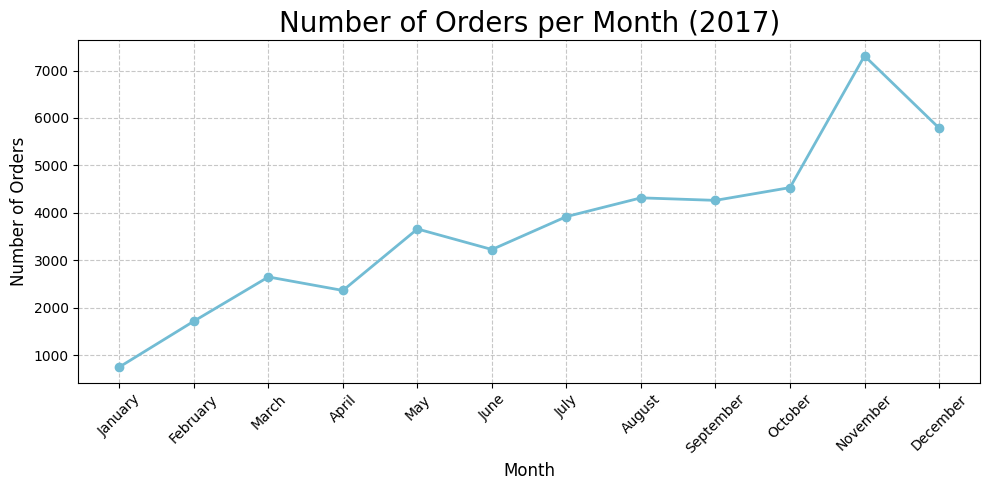

In [ ]:

all_df['order_approved_at'] = pd.to_datetime(all_df['order_approved_at'])

# Filter data untuk tahun 2017
all_df_2017 = all_df.loc[(all_df['order_approved_at'].dt.year == 2017)]


monthly_orders_df = all_df_2017.resample(rule='M', on='order_approved_at').agg({
    "order_id": "nunique",
    "price": "sum"
})


monthly_orders_df.index = monthly_orders_df.index.strftime('%B')

monthly_orders_df = monthly_orders_df.reset_index()
monthly_orders_df.rename(columns={
    "order_approved_at": "month",
    "order_id": "order_count",
    "price": "revenue"
}, inplace=True)

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_orders_df["month"],
    monthly_orders_df["order_count"],
    marker='o', linewidth=2, color="#72BCD4"
)
plt.title("Number of Orders per Month (2017)", loc="center", fontsize=20)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Berdasarkan visualisasi di atas, kita dapat melihat bahwa jumlah order terbanyak pada tahun 2017 terjadi pada bulan November. Selain itu, kita juga dapat melihat adanya penurunan jumlah order yang signifikan pada bulan April, Juni, dan Desember.

In [ ]:
# Bagaimana Performa Penjualan dan Revenue Perusahaan dalam Beberapa Bulan Terakhir pada tahun 2018?


all_df['order_approved_at'] = pd.to_datetime(all_df['order_approved_at'])

# Filter hanya untuk tahun 2018
all_df_2018 = all_df.loc[(all_df['order_approved_at'].dt.year == 2018)]


monthly_orders_df = all_df_2018.resample(rule='M', on='order_approved_at').agg({
    "order_id": "nunique",
    "price": "sum"
})


monthly_orders_df.index = monthly_orders_df.index.strftime('%Y-%m')


monthly_orders_df = monthly_orders_df.reset_index()
monthly_orders_df.rename(columns={
    "order_id": "order_count",
    "price": "revenue"
}, inplace=True)

print(monthly_orders_df.head())

<ipython-input-50-a44247a08302>:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = all_df_2018.resample(rule='M', on='order_approved_at').agg({


  order_approved_at  order_count     revenue
0           2018-01         7140   942892.57
1           2018-02         6675   837163.28
2           2018-03         7269   992982.10
3           2018-04         6772   976849.80
4           2018-05         7047  1018473.97


<ipython-input-73-77e3b7b653dc>:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = all_df_2018.resample(rule='M', on='order_approved_at').agg({


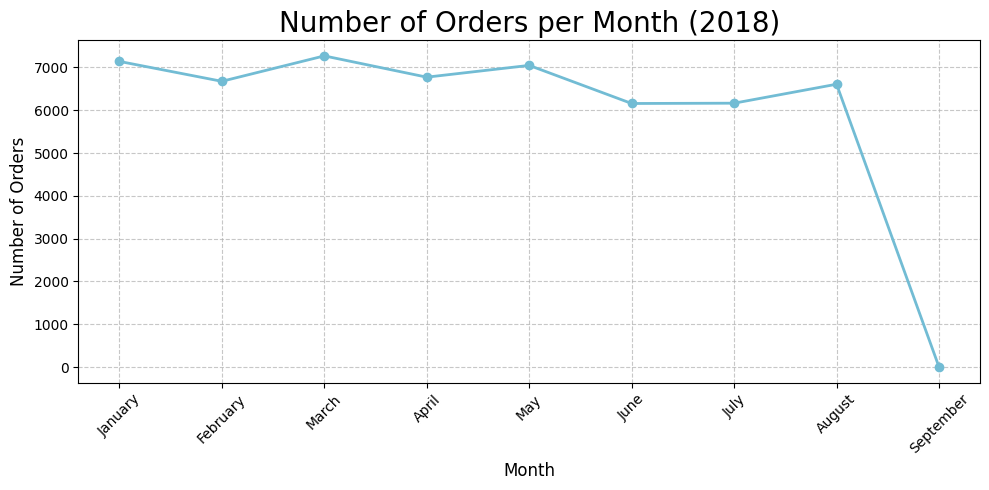

In [ ]:
all_df['order_approved_at'] = pd.to_datetime(all_df['order_approved_at'])

# Filter data untuk tahun 2018
all_df_2018 = all_df.loc[(all_df['order_approved_at'].dt.year == 2018)]


monthly_orders_df = all_df_2018.resample(rule='M', on='order_approved_at').agg({
    "order_id": "nunique",
    "price": "sum"
})


monthly_orders_df.index = monthly_orders_df.index.strftime('%B')

monthly_orders_df = monthly_orders_df.reset_index()
monthly_orders_df.rename(columns={
    "order_approved_at": "month",
    "order_id": "order_count",
    "price": "revenue"
}, inplace=True)

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_orders_df["month"],
    monthly_orders_df["order_count"],
    marker='o', linewidth=2, color="#72BCD4"
)
plt.title("Number of Orders per Month (2018)", loc="center", fontsize=20)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Sedangkan pada tahun 2018 kita dapat melihat bahwa jumlah order terbanyak terjadi pada bulan Maret. Selain itu, kita juga dapat melihat adanya penurunan jumlah order yang signifikan pada bulan Februari, April, Juni, dan September.

### Pertanyaan 2: Produk apa yang paling banyak dan sedikit terjual?

In [ ]:
#Produk Apa yang Paling Banyak dan Paling Sedikit Terjual?
sum_order_items_df = all_df.groupby("product_id").order_item_id.sum().sort_values(ascending=False).reset_index()
sum_order_items_df.head(15)

,product_id,order_item_id
0,422879e10f46682990de24d770e7f83d,793
1,aca2eb7d00ea1a7b8ebd4e68314663af,640
2,368c6c730842d78016ad823897a372db,551
3,53759a2ecddad2bb87a079a1f1519f73,545
4,99a4788cb24856965c36a24e339b6058,542
5,389d119b48cf3043d311335e499d9c6b,534
6,d1c427060a0f73f6b889a5c7c61f2ac4,369
7,a62e25e09e05e6faf31d90c6ec1aa3d1,367
8,53b36df67ebb7c41585e8d54d6772e08,359
9,3dd2a17168ec895c781a9191c1e95ad7,306


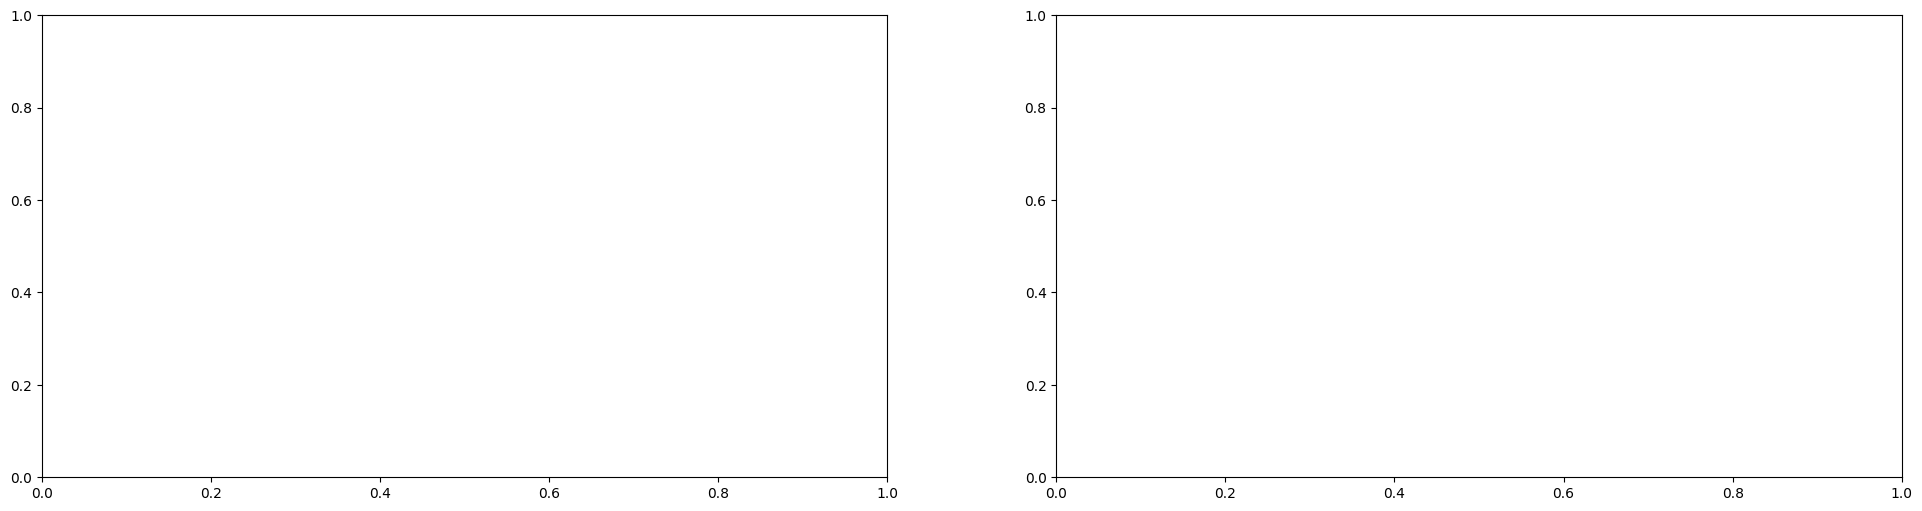

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

<ipython-input-74-562b01e57d79>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="order_item_id", y="product_id", data=sum_order_items_df.head(5), palette=colors, ax=ax[0])
<ipython-input-74-562b01e57d79>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="order_item_id", y="product_id", data=sum_order_items_df.sort_values(by="order_item_id", ascending=True).head(5), palette=colors, ax=ax[1])


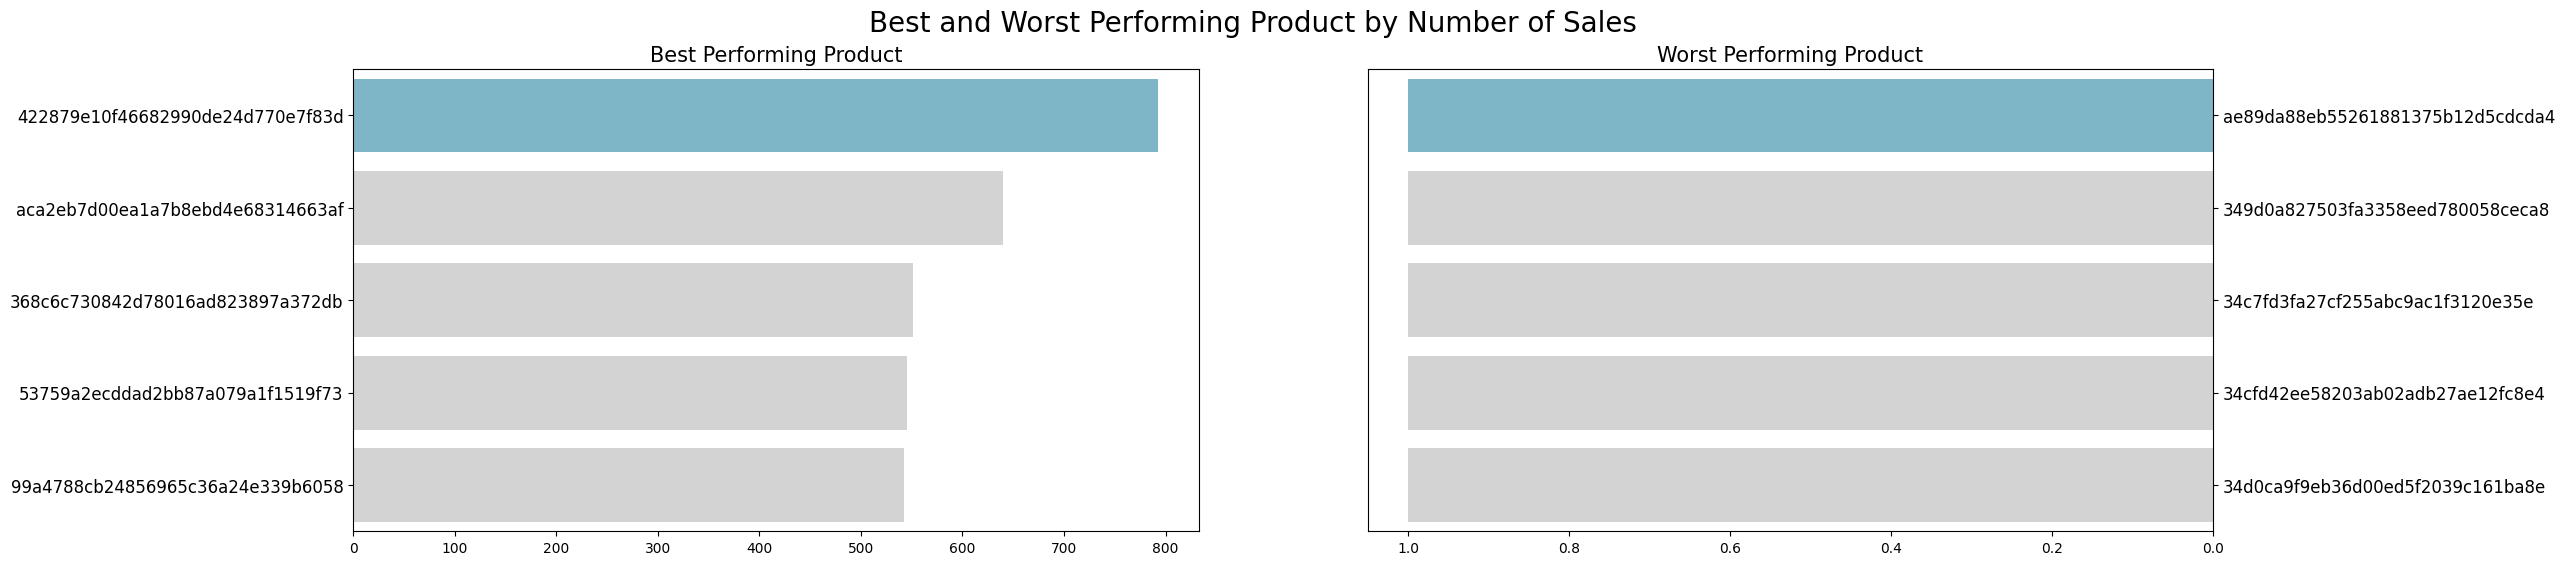

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="order_item_id", y="product_id", data=sum_order_items_df.head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Best Performing Product", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

sns.barplot(x="order_item_id", y="product_id", data=sum_order_items_df.sort_values(by="order_item_id", ascending=True).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Product", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Best and Worst Performing Product by Number of Sales", fontsize=20)
plt.show()

Berdasarkan gambar di atas, Anda dapat melihat bahwa produk dengan id 422879e10f46682990de24d770e7f83d merupakan produk yang paling laris terjual dengan total terjual hingga 793 order. Kontras dengan hal tersebut, produk dengan id 7c1bd920dbdf22470b68bde975dd3ccf merupakan produk yang paling sedikit terjual dengan total terjual 241.  

### Pertanyaan 3: Bagaimana demografi pelanggan yang kita miliki?

<ipython-input-59-290e6aea636b>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-59-290e6aea636b>:11: UserWarning: 
The palette list has fewer values (8) than needed (27) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


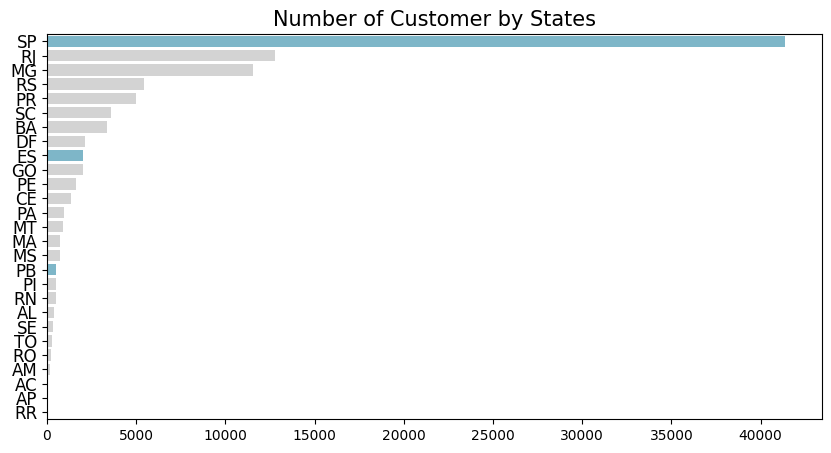

In [ ]:
#Bagaimana Demografi Pelanggan yang Kita Miliki?

#Berdasarkan State
bystate_df = all_df.groupby(by="customer_state").customer_id.nunique().reset_index()
bystate_df.rename(columns={
    "customer_id": "customer_count"
}, inplace=True)
bystate_df
plt.figure(figsize=(10, 5))
colors_ = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
sns.barplot(
    x="customer_count",
    y="customer_state",
    data=bystate_df.sort_values(by="customer_count", ascending=False),
    palette=colors_
)
plt.title("Number of Customer by States", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel(None)
plt.tick_params(axis='y', labelsize=12)
plt.show()

Berdasarkan visualisasi data tersebut, dapat diketahui bahwa pelanggan yang kita miliki paling banyak berasal dari negara bagian Sao Paulo.

<ipython-input-102-b9a6358b2a27>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-102-b9a6358b2a27>:14: UserWarning: 
The palette list has fewer values (8) than needed (33) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


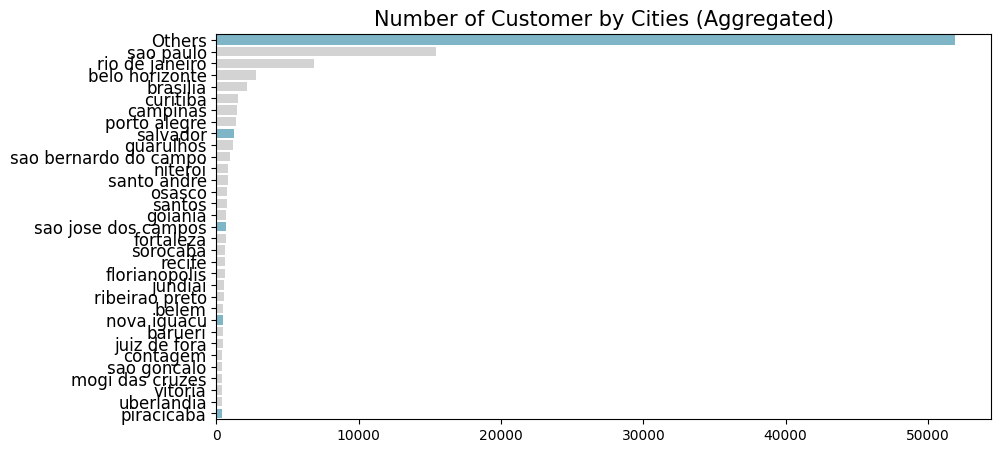

In [ ]:
# Tetapkan ambang batas
threshold = 360

# Buat kolom baru untuk pengelompokan
bycity_df['customer_city_grouped'] = bycity_df.apply(
    lambda row: row['customer_city'] if row['customer_count'] >= threshold else 'Others', axis=1
)

# Agregasi ulang berdasarkan kategori baru
bycity_aggregated = bycity_df.groupby('customer_city_grouped', as_index=False).customer_count.sum()

# Visualisasi
plt.figure(figsize=(10, 5))
sns.barplot(
    x="customer_count",
    y="customer_city_grouped",
    data=bycity_aggregated.sort_values(by="customer_count", ascending=False),
    palette=colors_
)
plt.title("Number of Customer by Cities (Aggregated)", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel(None)
plt.tick_params(axis='y', labelsize=12)
plt.show()

Dikarenakan kita menggunakan threshold untuk hanya menampilkan kota-kota utama, maka kita dapat mengetahui bahwa pelanggan yang kita miliki paling banyak berasal dari Kota Sao Paulo lalu diikuti oleh Kota Rio de Janeiro dan kota Belo Horizonte

### Pertanyaan 4: Kapan terakhir pelanggan melakukan transaksi?

In [ ]:
#RFM Analysis
rfm_df = all_df.groupby(by="customer_id", as_index=False).agg({
    "order_approved_at": "max",
    "order_id": "nunique",
    "price": "sum"
})
rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]


rfm_df["max_order_timestamp"] = pd.to_datetime(rfm_df["max_order_timestamp"]).dt.date

# Pastikan semua nilai NaT ditangani sebelum menghitung 'recency'
valid_order_dates = rfm_df["max_order_timestamp"].dropna()  # Hanya ambil nilai valid
recent_date = valid_order_dates.max() if not valid_order_dates.empty else pd.Timestamp.today().date()

# Menghitung recency, dengan menangani nilai NaT
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(
    lambda x: (recent_date - x).days if pd.notnull(x) else None
)

rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

print(rfm_df.head())

                        customer_id  frequency  monetary  recency
0  00012a2ce6f8dcda20d059ce98491703          1     89.80    293.0
1  000161a058600d5901f007fab4c27140          1     54.90    414.0
2  0001fd6190edaaf884bcaf3d49edf079          1    179.99    552.0
3  0002414f95344307404f0ace7a26f1d5          1    149.90    382.0
4  000379cdec625522490c315e70c7a9fb          1     93.00    152.0


<ipython-input-71-0ab863ec4cb7>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="short_customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
<ipython-input-71-0ab863ec4cb7>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="short_customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
<ipython-input-71-0ab863ec4cb7>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="monetary", x="short_customer_id", data=rfm_d

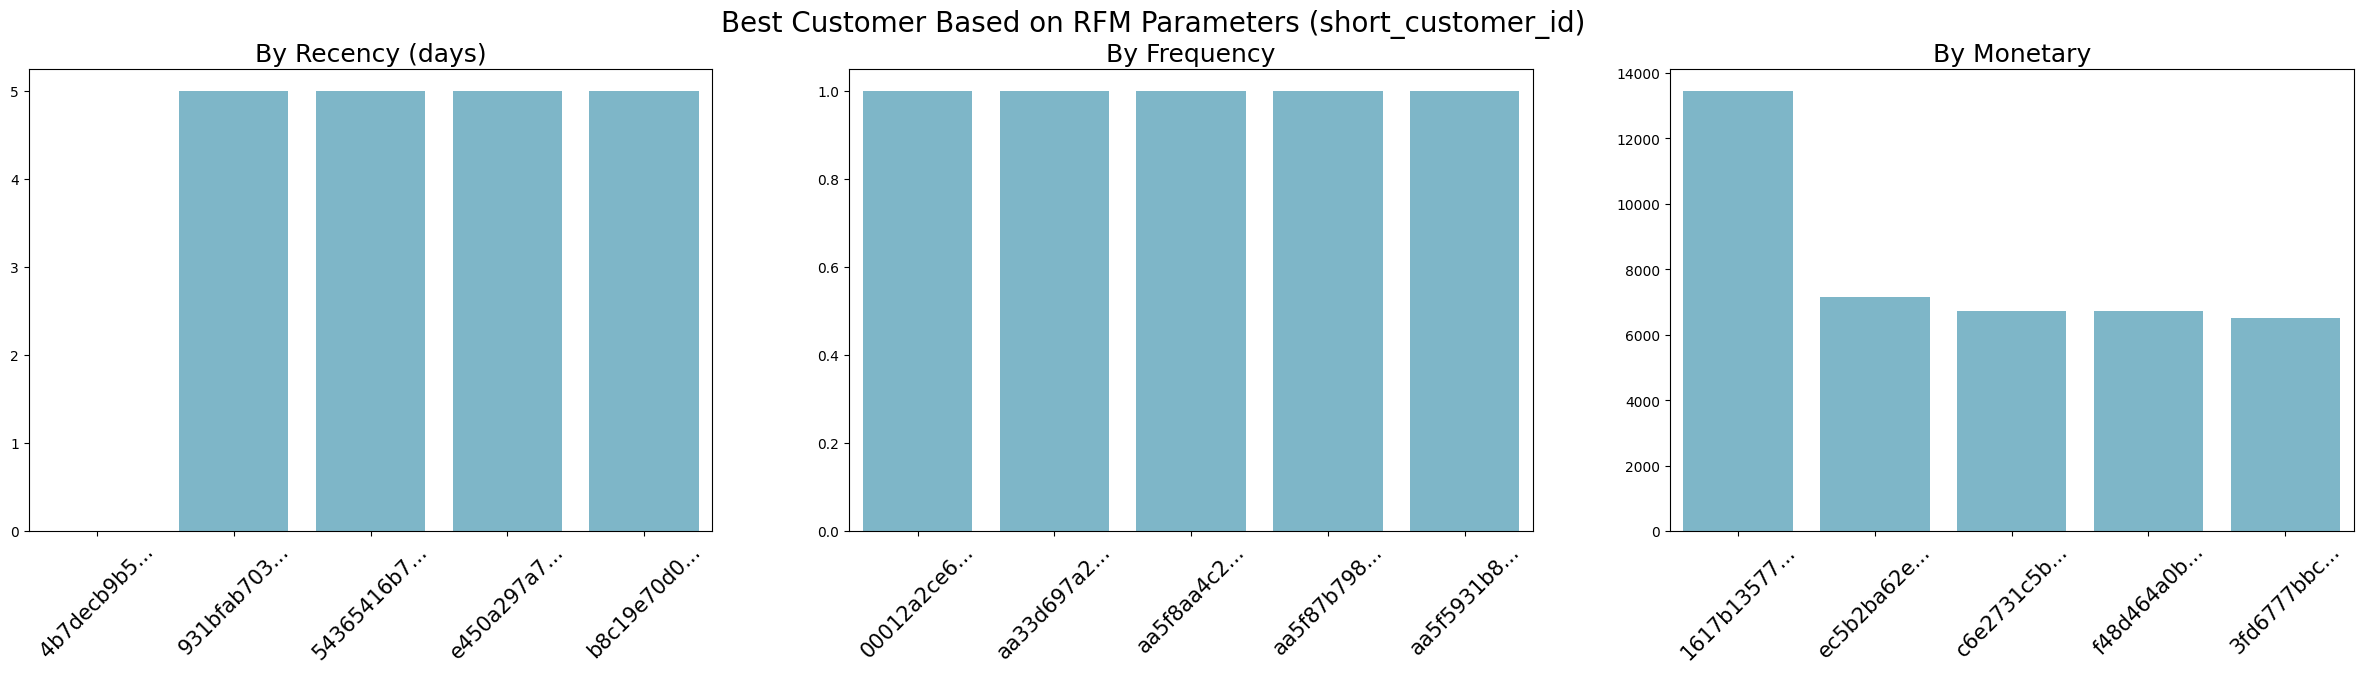

In [ ]:
rfm_df['short_customer_id'] = rfm_df['customer_id'].apply(lambda x: x[:10] + '...' if len(x) > 10 else x)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

sns.barplot(y="recency", x="short_customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis='x', labelsize=15, labelrotation=45)

sns.barplot(y="frequency", x="short_customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=15, labelrotation=45)

sns.barplot(y="monetary", x="short_customer_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=15, labelrotation=45)

plt.suptitle("Best Customer Based on RFM Parameters (short_customer_id)", fontsize=20)
plt.show()

### Pertanyaan 5: Seberapa sering seorang pelanggan melakukan pembelian dalam beberapa bulan terakhir?

Berdasarkan visualisasi data tersebut, dapat diketahui bahwa pelanggan yang melakukan pembelian dalam beberapa bulan terakhir adalah melakukan 1 kali pembelian

### Pertanyaan 6: Berapa banyak uang yang dihabiskan pelanggan dalam beberapa bulan terakhir?

Sedangkan banyak uang yang dihabiskan pelanggan dalam beberapa bulan terakhir memiliki total pengeluaran sebanyak hampir 14000 dolar


**Insight:**
- Mayoritas pelanggan hanya melakukan 1 kali pembelian dalam beberapa bulan terakhir, yang mengindikasikan tingkat repeat order yang masih rendah dan berpotensi menjadi fokus strategi retensi pelanggan.
- Total pengeluaran pelanggan dalam beberapa bulan terakhir mencapai hampir 14.000 dolar, menunjukkan kontribusi pelanggan aktif terhadap revenue perusahaan cukup signifikan meskipun frekuensi pembelian per pelanggan masih rendah.
- Kombinasi recency, frequency, dan monetary (RFM) ini dapat dimanfaatkan untuk mengidentifikasi pelanggan terbaik (best customers) sebagai target program loyalitas atau promosi lanjutan.

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1
- Conclution pertanyaan 2

In [ ]:
all_df.to_csv("all_data.csv", index=False)